### 07 - Comparaison des modeles de classification (etude comparative)
#### HumanForYou - Attrition ML

**Objectif** : reproduire la partie "etude comparative" du workshop avec les donnees du projet :
- Comparaison des metriques (7 modeles)
- Cross-validation 5-fold (estimation robuste)
- Courbes Precision-Recall et ROC
- Temps d'entrainement/prediction
- **Choix du modele final** avec justification
- **Pistes d'amelioration**

#### 1. Imports


In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


#### 2. Chargement des donnees preparees


In [2]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
train_path = os.path.join(PROCESSED_DIR, 'attrition_train_prepared.csv')
test_path = os.path.join(PROCESSED_DIR, 'attrition_test_prepared.csv')

assert os.path.exists(train_path), f'Fichier introuvable: {train_path}'
assert os.path.exists(test_path), f'Fichier introuvable: {test_path}'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train = train_df.drop(columns=['Attrition']).copy()
y_train = train_df['Attrition'].astype(int).copy()
X_test = test_df.drop(columns=['Attrition']).copy()
y_test = test_df['Attrition'].astype(int).copy()

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')


X_train: (3087, 46) | X_test: (1323, 46)


#### 3. Cross-validation (comme comparaison workshop)


In [3]:
models = {
    'Perceptron': Perceptron(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'SVC': SVC( C=0.5, kernel='rbf', gamma='scale', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=3),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_split=10, min_samples_leaf=5, max_samples=0.8, class_weight='balanced', random_state=42, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for model_name, model in models.items():
    f1_scores = cross_val_score(model, X_train, y_train, scoring='f1', cv=cv, n_jobs=1)
    auc_scores = cross_val_score(model, X_train, y_train, scoring='roc_auc', cv=cv, n_jobs=1)

    cv_rows.append({
        'model': model_name,
        'f1_cv_mean': float(f1_scores.mean()),
        'f1_cv_std': float(f1_scores.std()),
        'roc_auc_cv_mean': float(auc_scores.mean()),
        'roc_auc_cv_std': float(auc_scores.std()),
    })

cv_df = pd.DataFrame(cv_rows).sort_values('f1_cv_mean', ascending=False).reset_index(drop=True)
cv_df


,model,f1_cv_mean,f1_cv_std,roc_auc_cv_mean,roc_auc_cv_std
0,RandomForest,0.724356,0.023586,0.940723,0.008604
1,NaiveBayes,0.426602,0.017398,0.739257,0.034673
2,LogisticRegression,0.384899,0.037181,0.812601,0.014254
3,Perceptron,0.357515,0.087543,0.710850,0.037805
4,SVC,0.354800,0.027829,0.919253,0.013502
5,KNN,0.343666,0.047025,0.830510,0.022091
6,DecisionTree,0.272658,0.049062,0.707891,0.016587


#### 4. Entrainement final test + timings


In [4]:
def get_positive_proba(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        raw = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))
    return model.predict(X).astype(float)


comparison_rows = []
predictions_df = pd.DataFrame({'y_true': y_test})
timing_rows = []
fitted_models = {}
y_proba_by_model = {}

for model_name, model in models.items():
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    y_pred = model.predict(X_test)
    y_proba = get_positive_proba(model, X_test)
    pred_time = time.perf_counter() - start_pred

    fitted_models[model_name] = model
    y_proba_by_model[model_name] = y_proba

    predictions_df[f'y_pred_{model_name}'] = y_pred
    predictions_df[f'y_proba_{model_name}'] = y_proba

    comparison_rows.append({
        'model': model_name,
        'accuracy_test': float(accuracy_score(y_test, y_pred)),
        'precision_test': float(precision_score(y_test, y_pred, zero_division=0)),
        'recall_test': float(recall_score(y_test, y_pred, zero_division=0)),
        'f1_test': float(f1_score(y_test, y_pred, zero_division=0)),
        'roc_auc_test': float(roc_auc_score(y_test, y_proba)),
    })

    timing_rows.append({
        'model': model_name,
        'training_time_seconds': float(train_time),
        'prediction_time_seconds': float(pred_time),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('f1_test', ascending=False).reset_index(drop=True)
timing_df = pd.DataFrame(timing_rows)

comparison_df


,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,RandomForest,0.916100,0.752475,0.713615,0.732530,0.951601
1,SVC,0.880574,0.910448,0.286385,0.435714,0.914880
2,NaiveBayes,0.825397,0.451613,0.394366,0.421053,0.762594
3,Perceptron,0.812547,0.410256,0.375587,0.392157,0.734581
4,LogisticRegression,0.855631,0.622222,0.262911,0.369637,0.809237
5,KNN,0.831444,0.460938,0.276995,0.346041,0.874861
6,DecisionTree,0.851096,0.722222,0.122066,0.208835,0.728973


#### 5. Visualisations comparatives


Saved: ..\reports\figures\attrition_models_f1_test.png
Saved: ..\reports\figures\attrition_models_precision_recall.png
Saved: ..\reports\figures\attrition_models_roc_curve.png
Saved: ..\reports\figures\attrition_best_model_roc_curve.png
Saved: ..\reports\figures\attrition_models_prf_boxplot.png


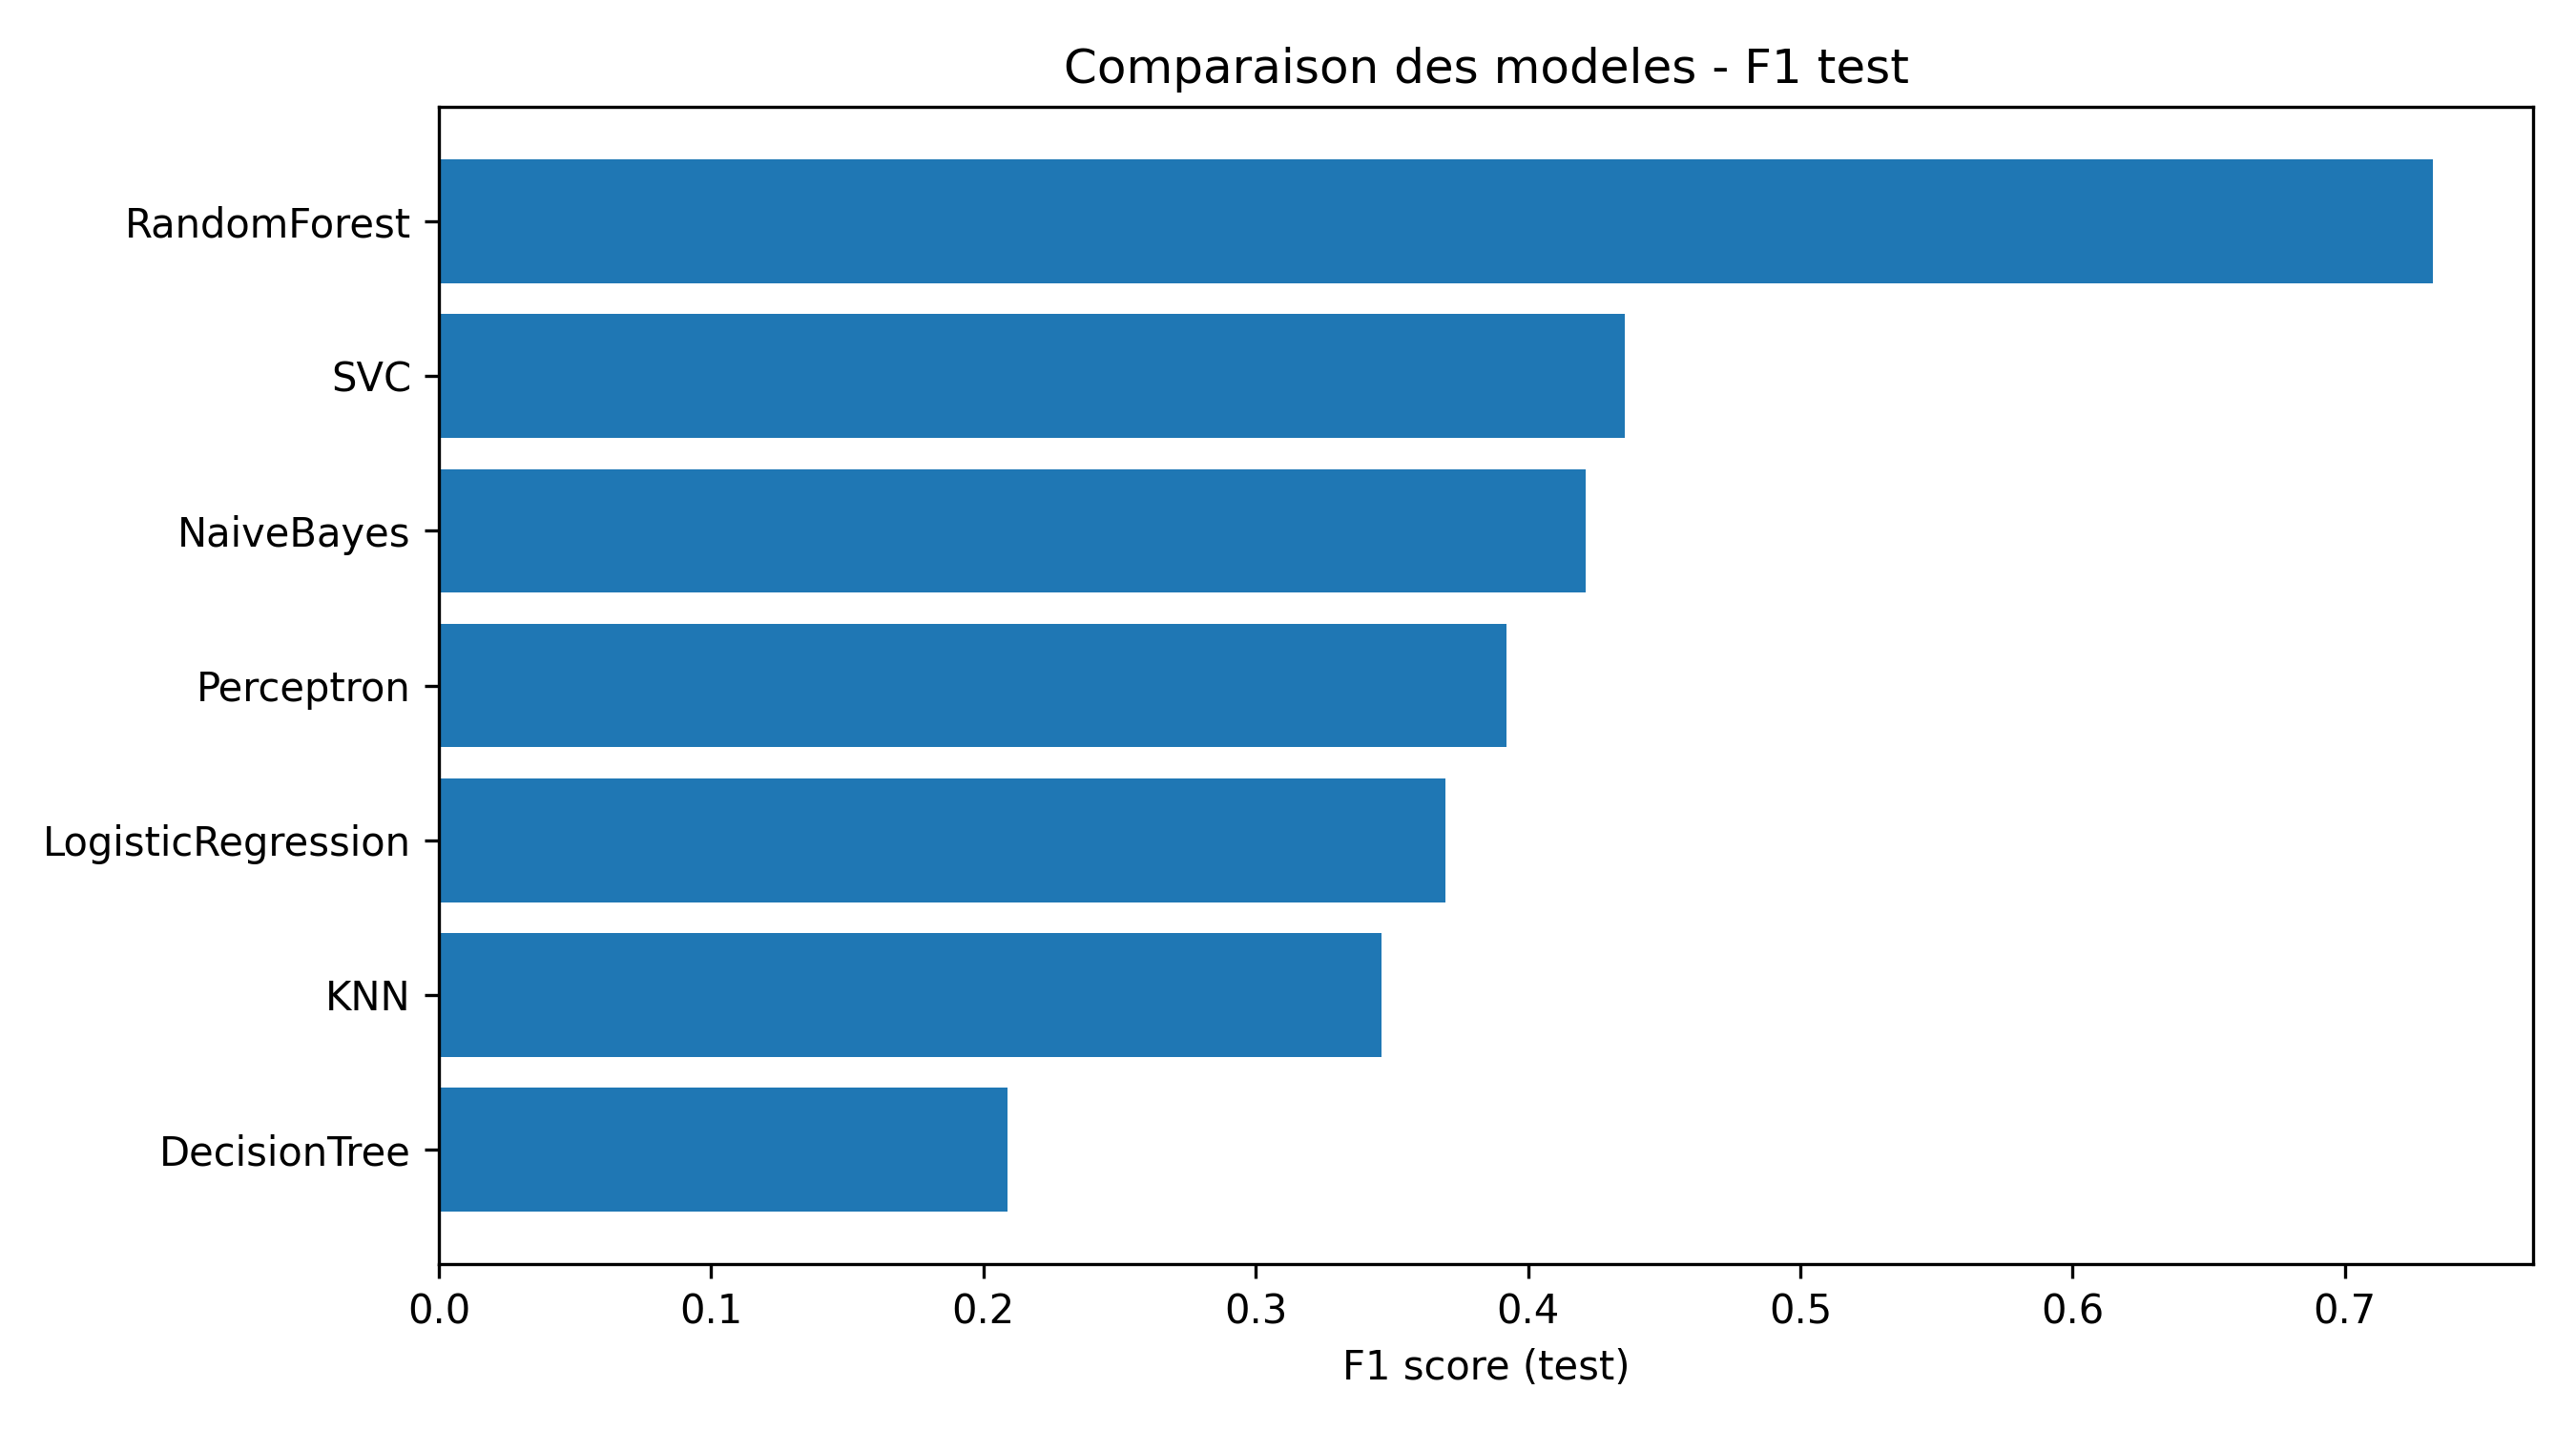

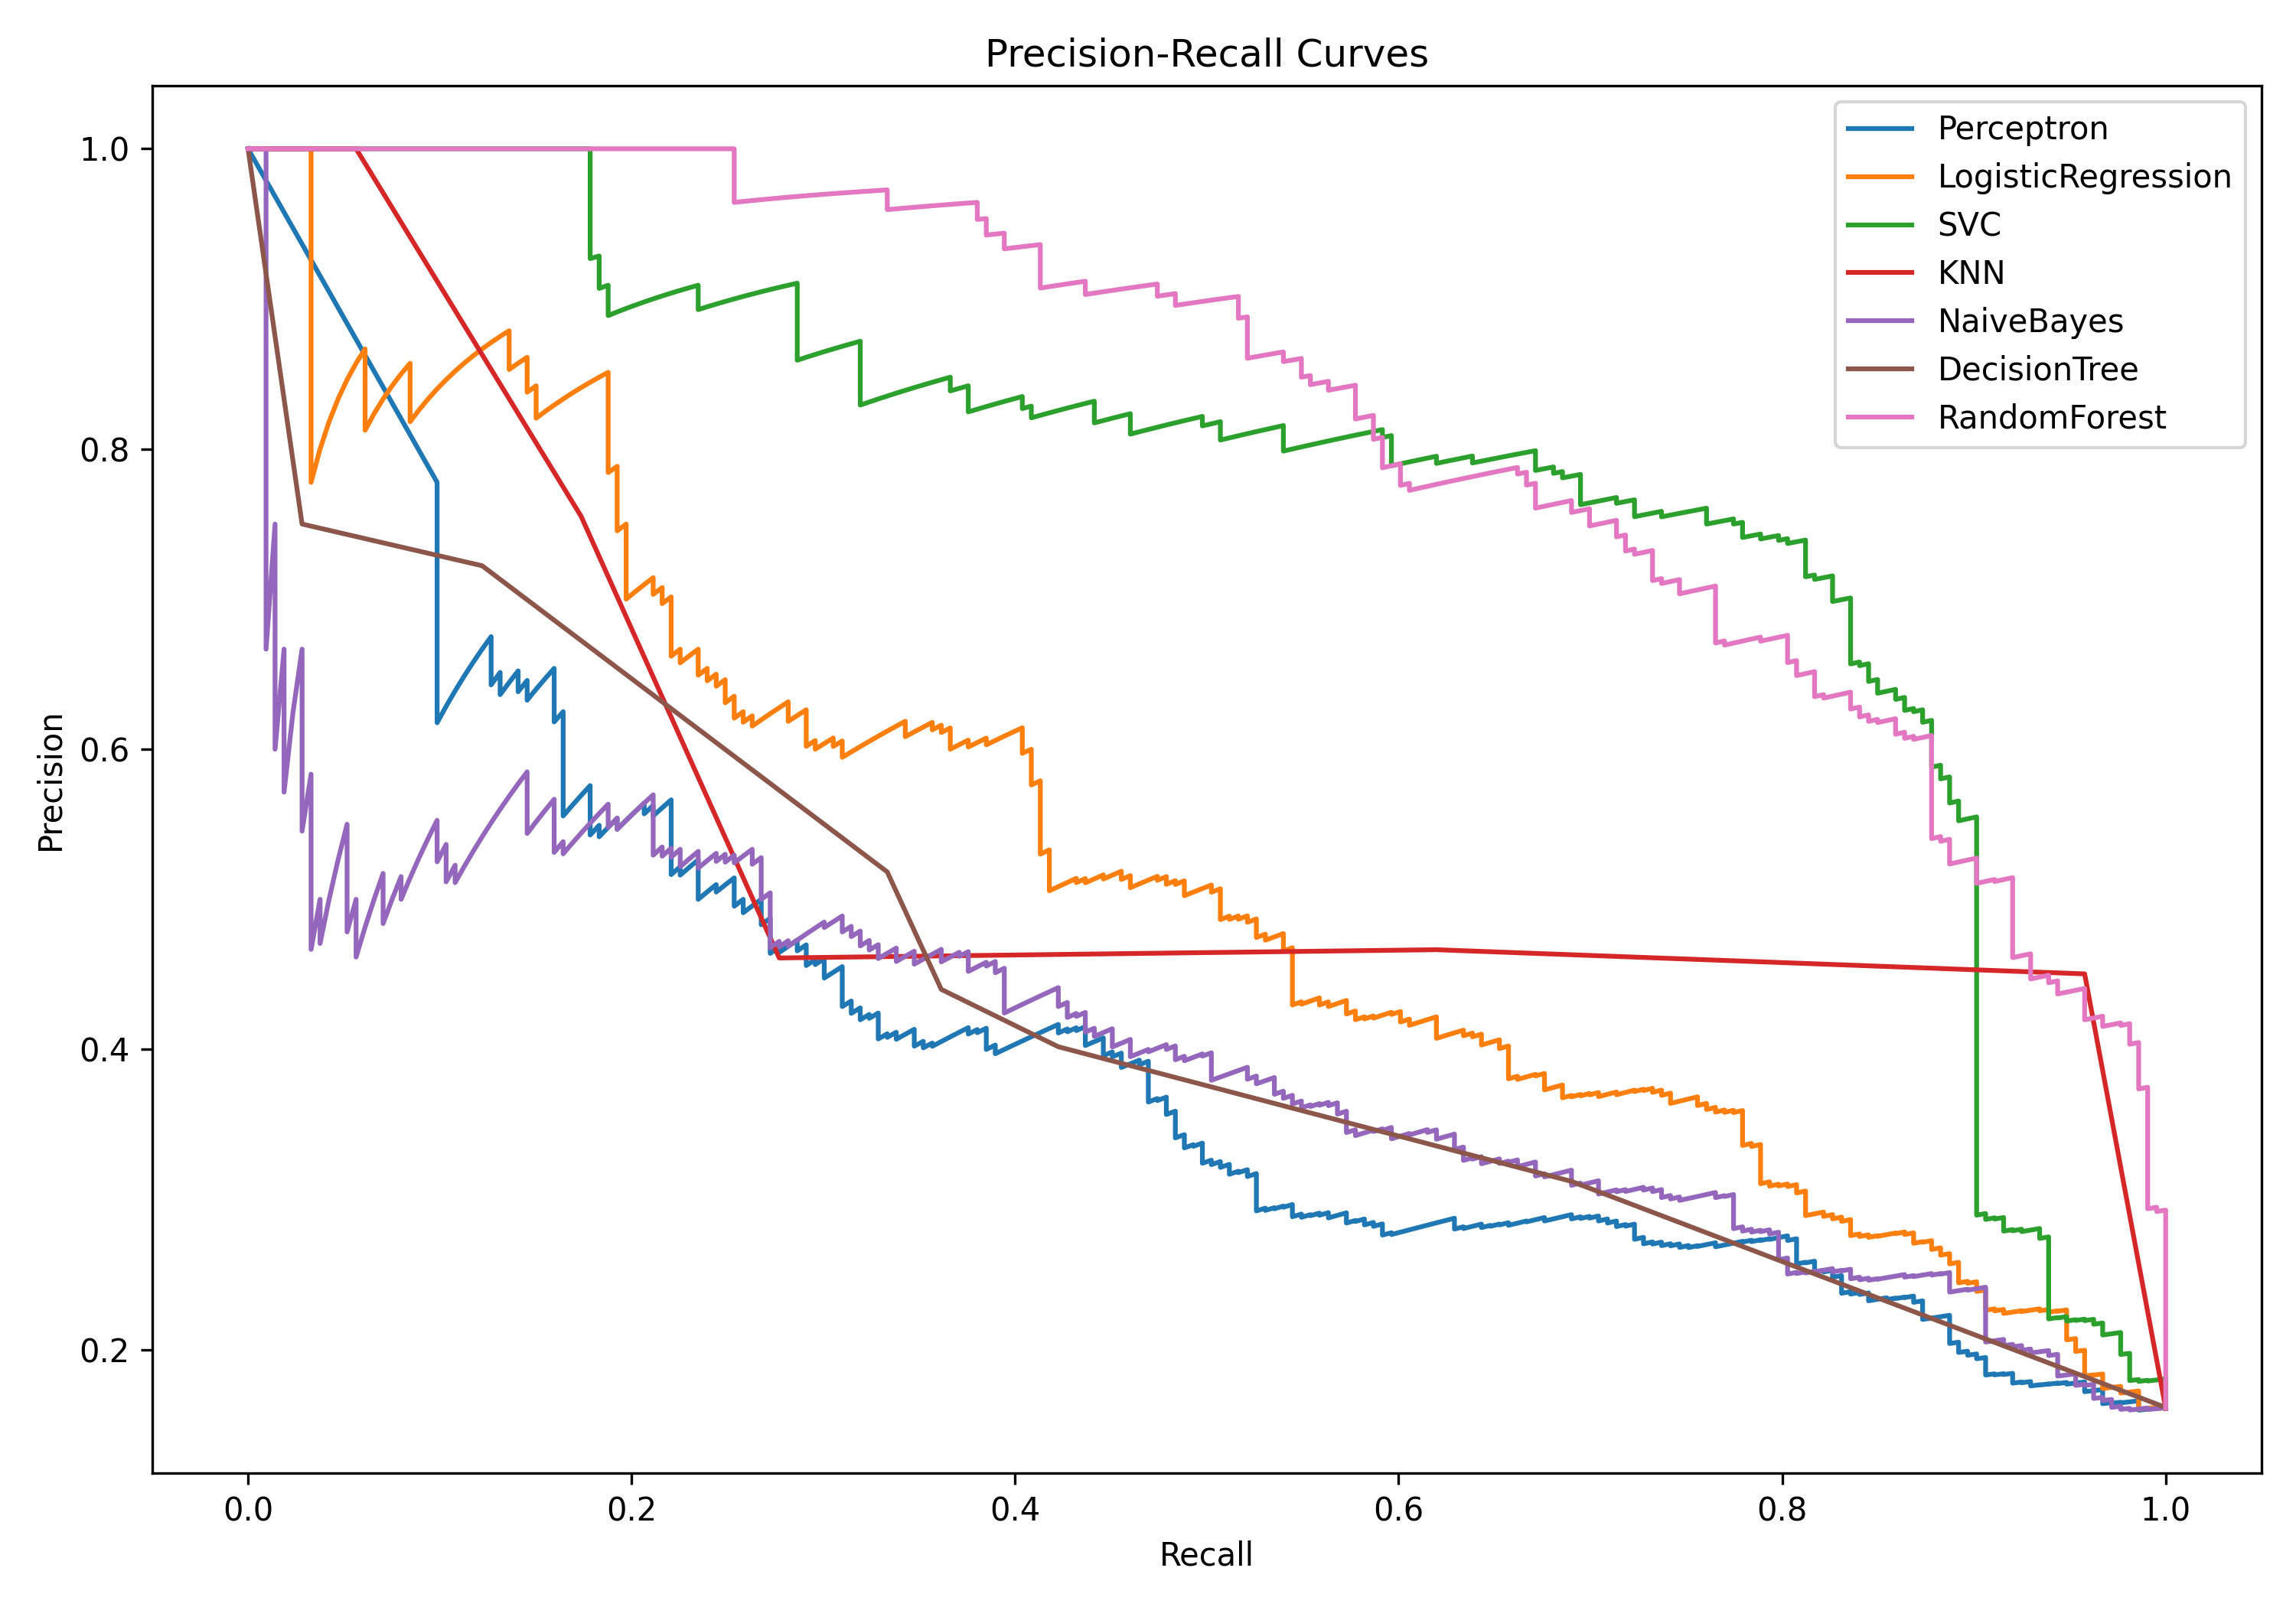

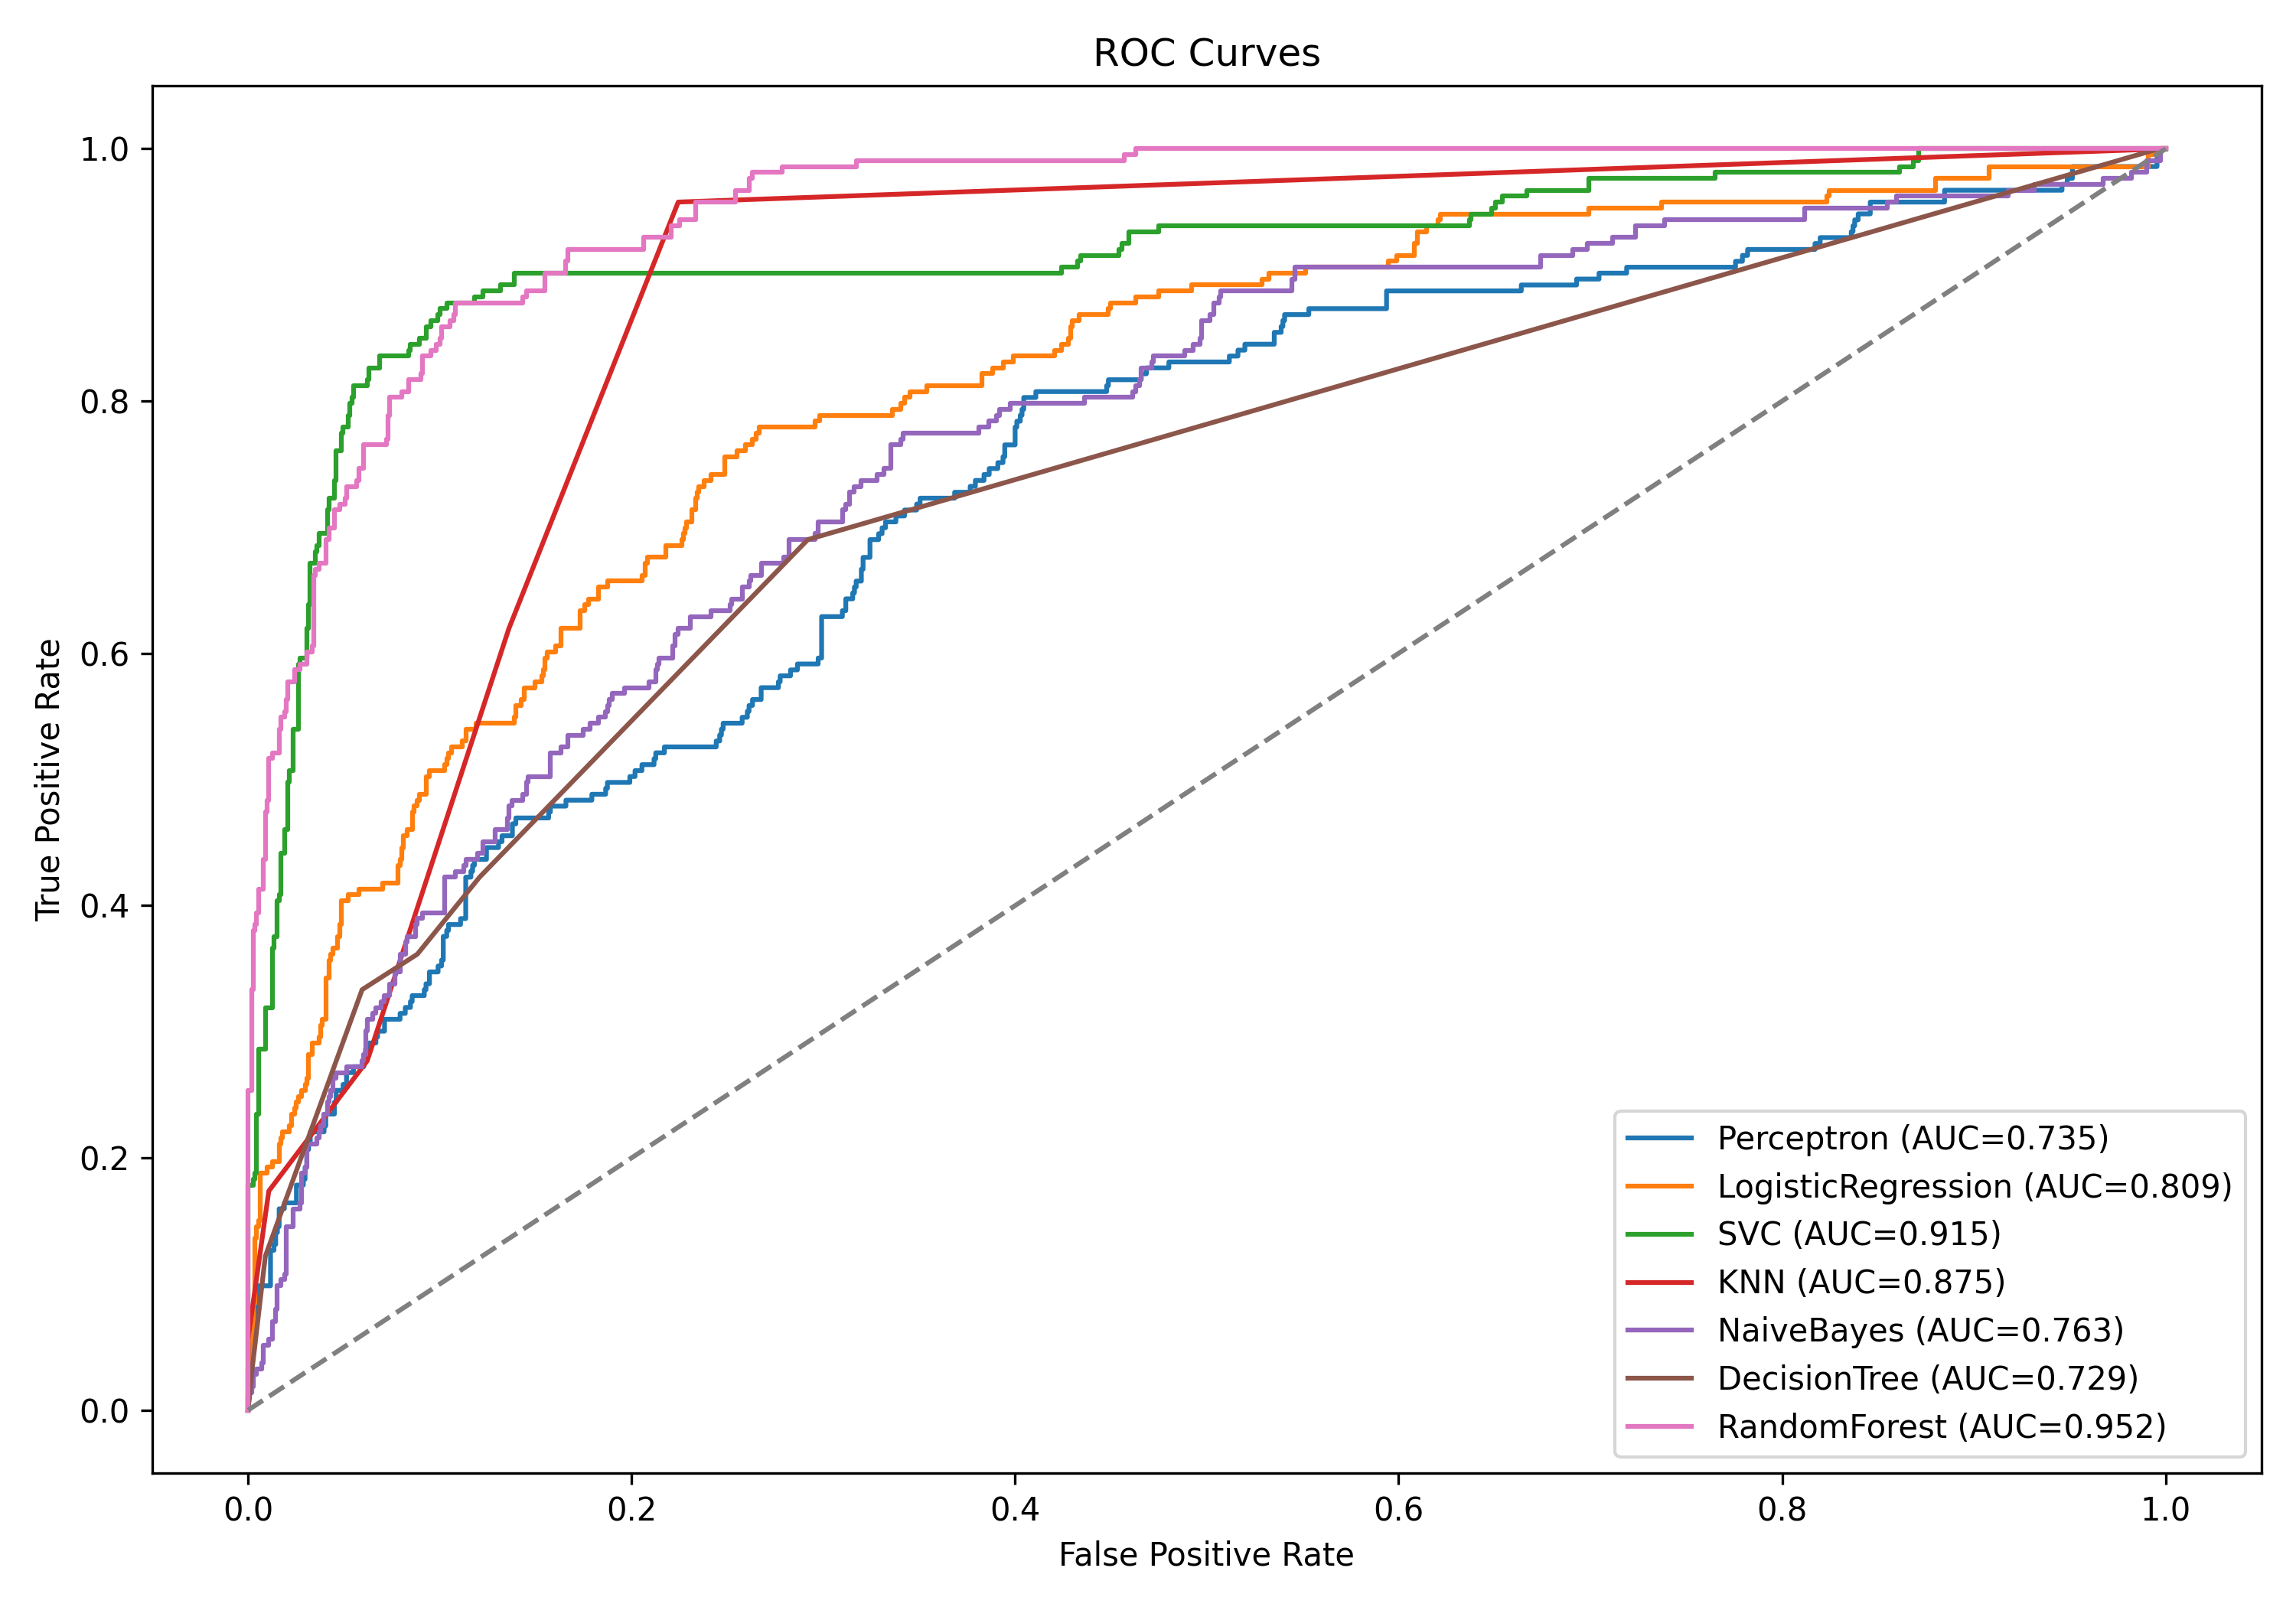

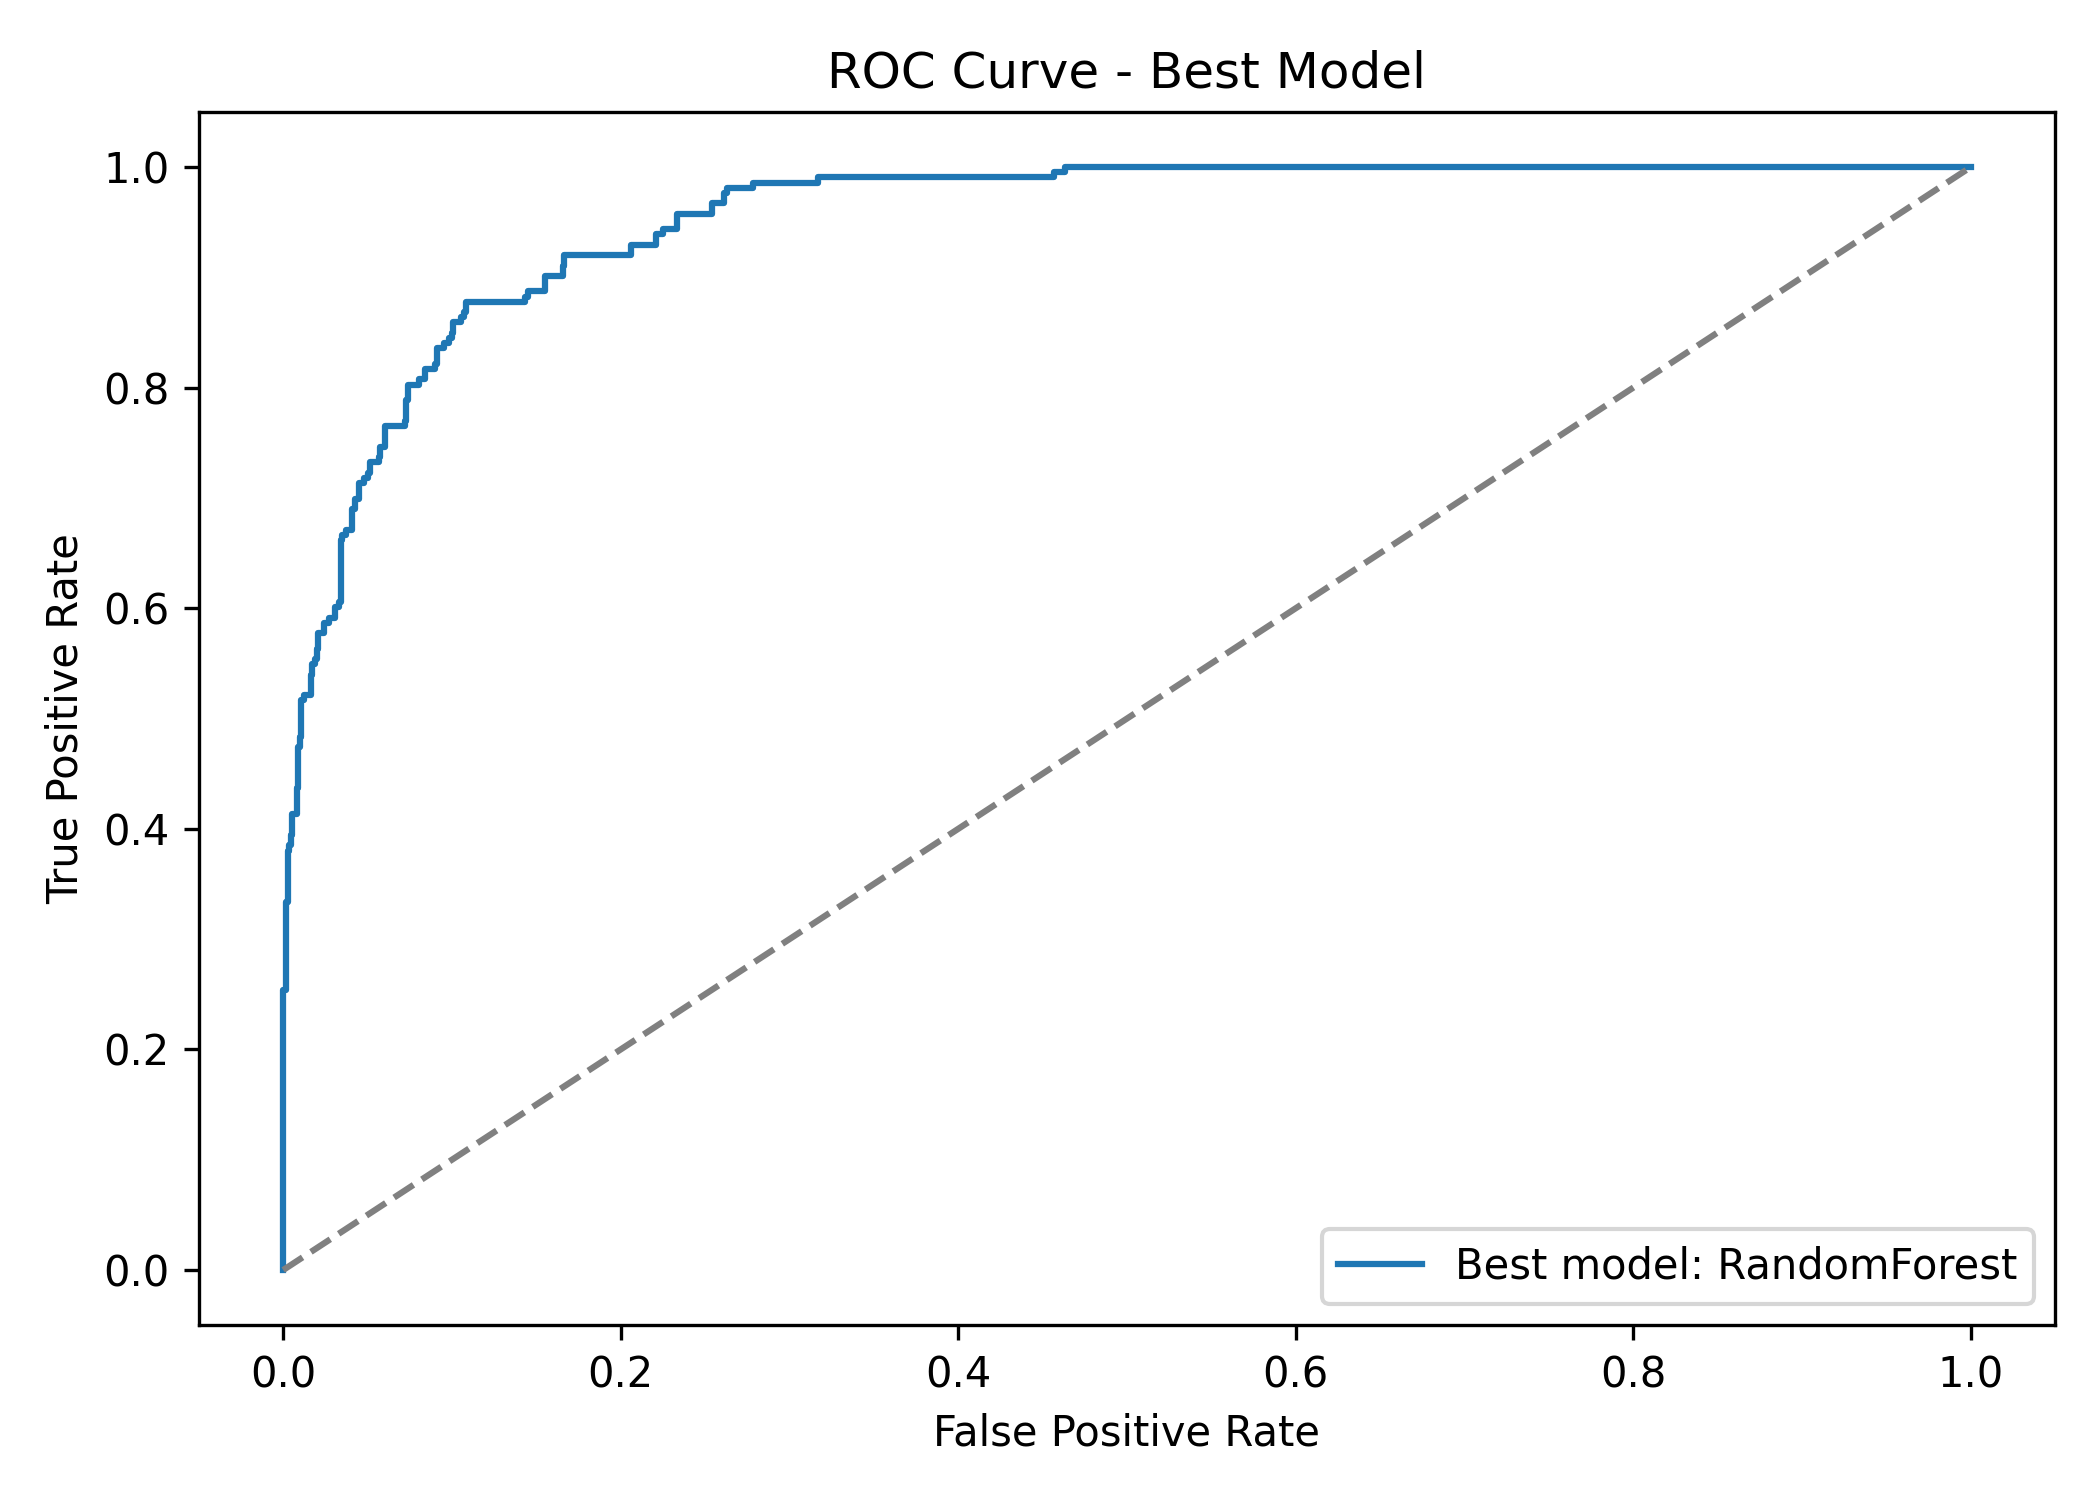

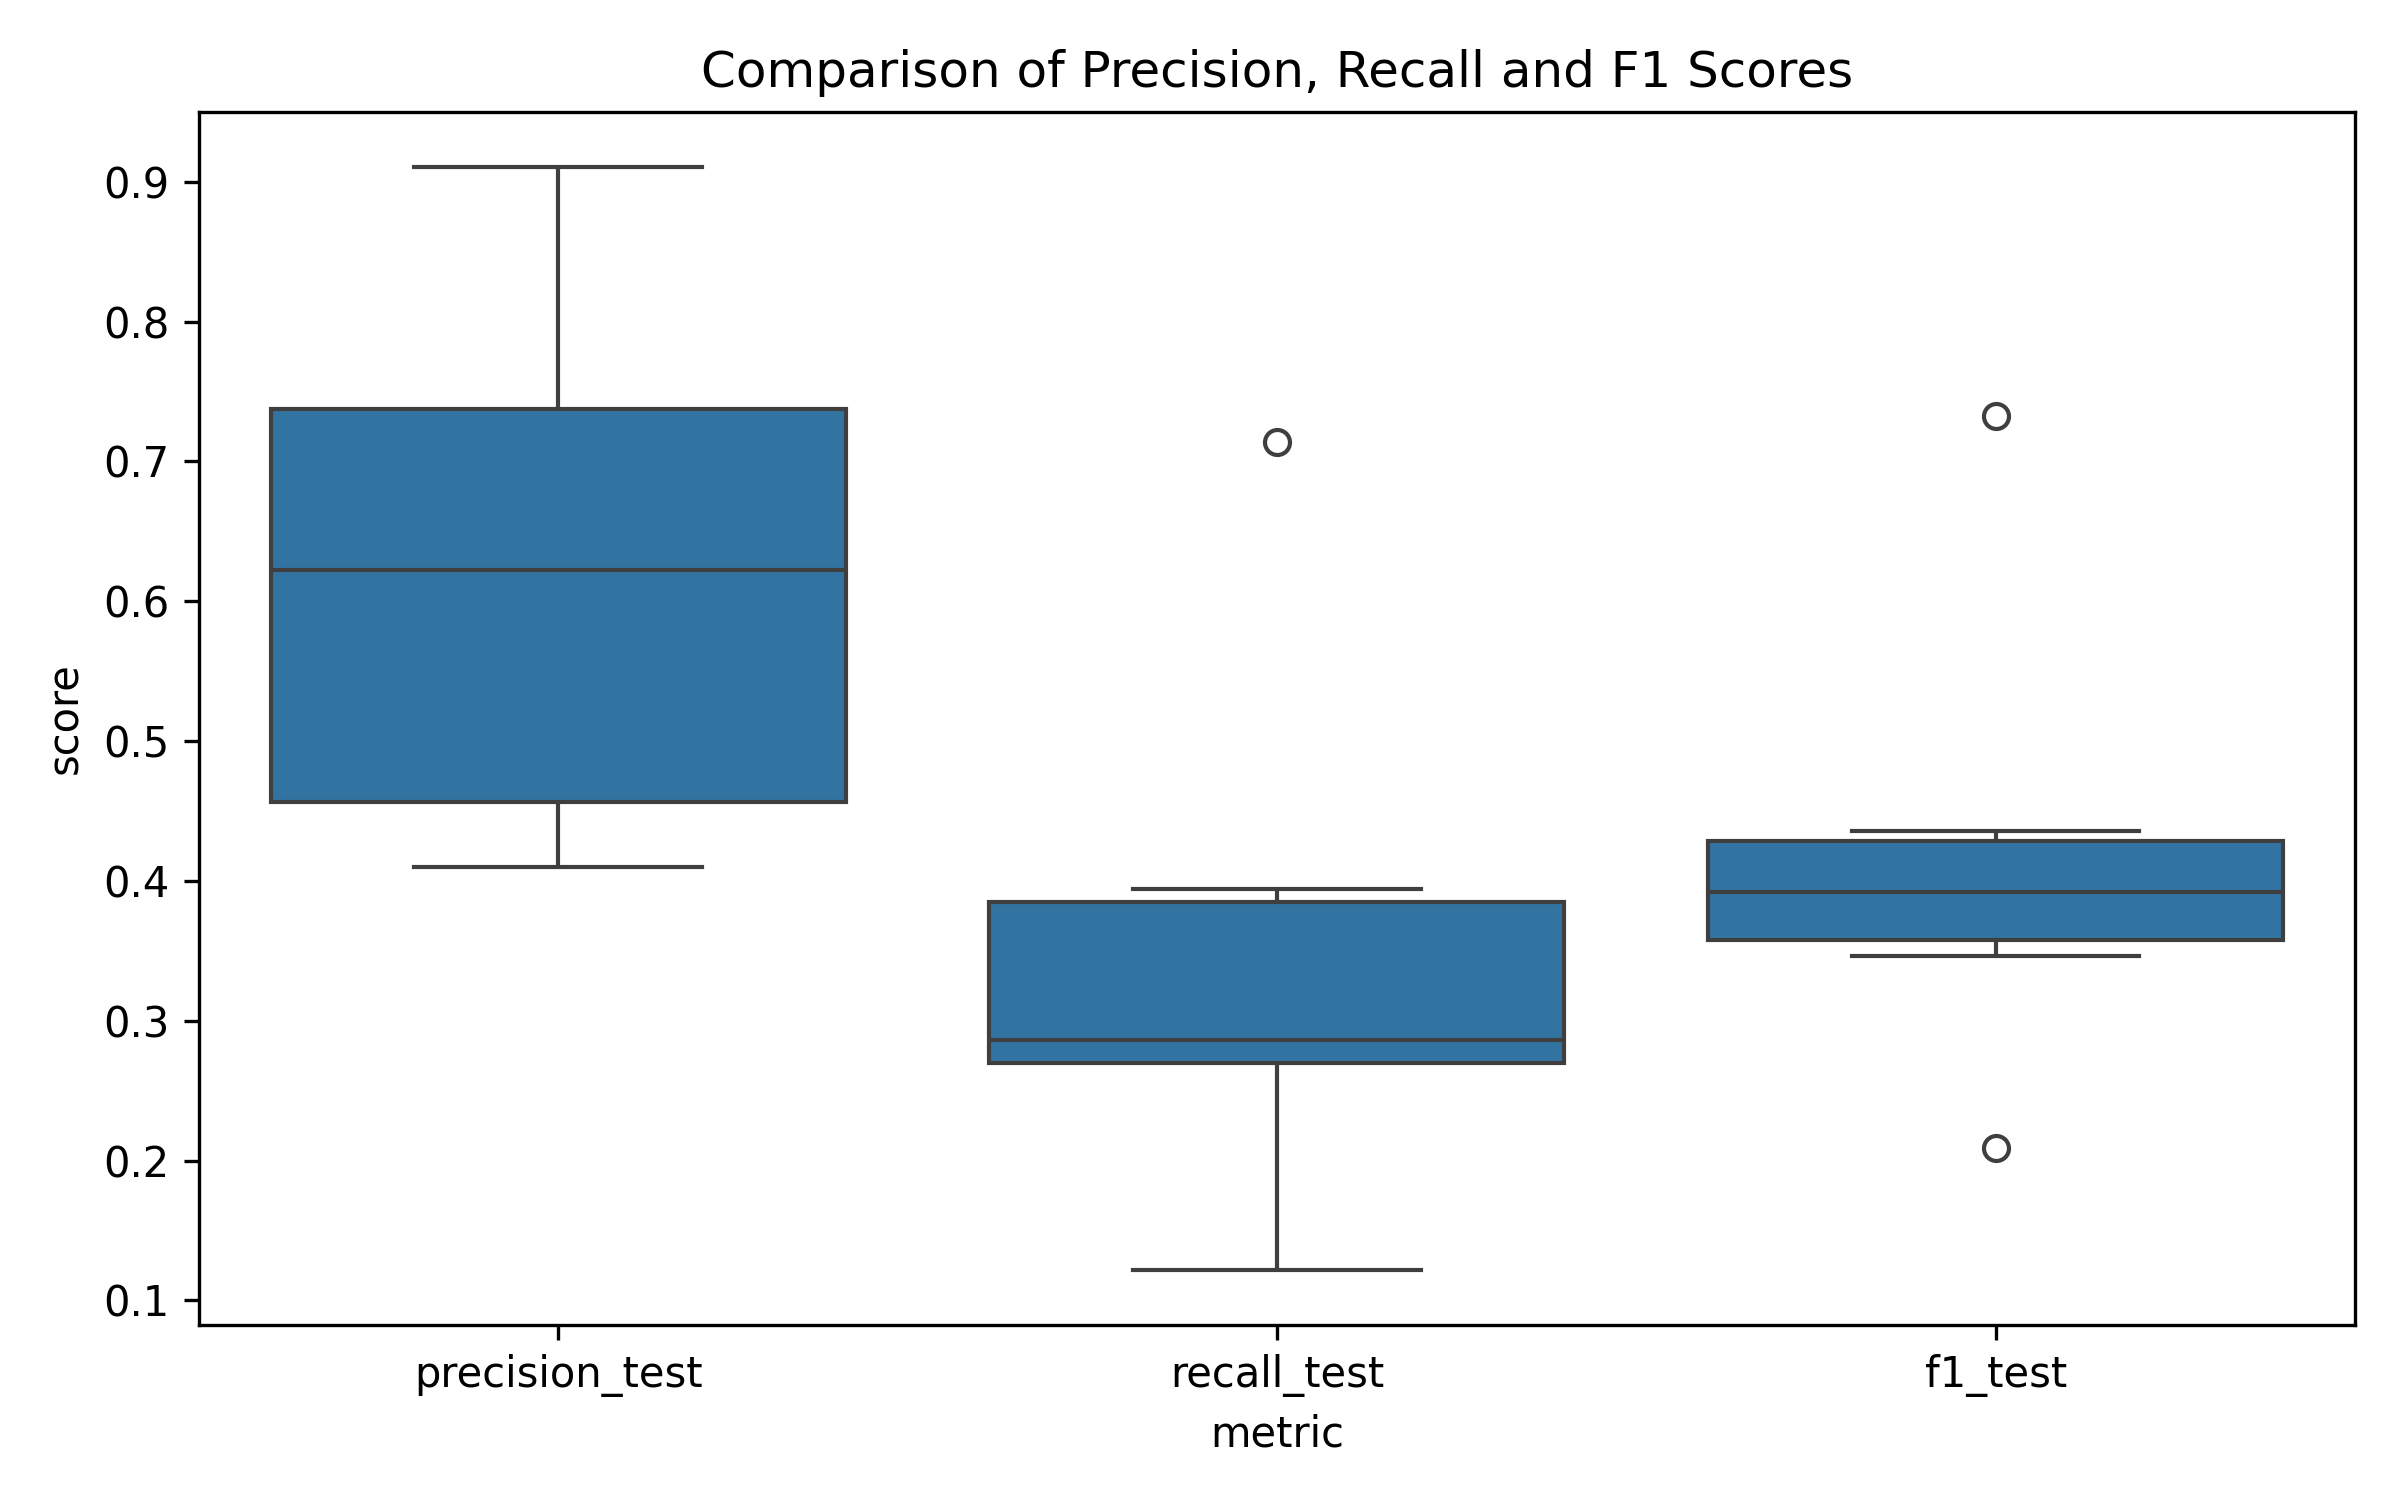

In [9]:
FIG_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# F1 test par modele
plot_df = comparison_df.sort_values('f1_test', ascending=True)
plt.figure(figsize=(9, 5))
plt.barh(plot_df['model'], plot_df['f1_test'])
plt.xlabel('F1 score (test)')
plt.title('Comparaison des modeles - F1 test')
plt.tight_layout()
f1_fig_path = os.path.join(FIG_DIR, 'attrition_models_f1_test.png')
plt.savefig(f1_fig_path, dpi=300)
plt.close()

# Precision-Recall curve multi-modeles
plt.figure(figsize=(10, 7))
for model_name, y_proba in y_proba_by_model.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=model_name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='best')
plt.tight_layout()
pr_fig_path = os.path.join(FIG_DIR, 'attrition_models_precision_recall.png')
plt.savefig(pr_fig_path, dpi=300)
plt.close()

# ROC curve multi-modeles
plt.figure(figsize=(10, 7))
for model_name, y_proba in y_proba_by_model.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
roc_fig_path = os.path.join(FIG_DIR, 'attrition_models_roc_curve.png')
plt.savefig(roc_fig_path, dpi=300)
plt.close()

# Figure historique du meilleur modele (compatibilite)
best_model_name = comparison_df.iloc[0]['model']
best_proba = y_proba_by_model[best_model_name]
fpr_best, tpr_best, _ = roc_curve(y_test, best_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr_best, tpr_best, label=f'Best model: {best_model_name}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Model')
plt.legend(loc='lower right')
plt.tight_layout()
best_roc_fig_path = os.path.join(FIG_DIR, 'attrition_best_model_roc_curve.png')
plt.savefig(best_roc_fig_path, dpi=300)
plt.close()

# Boxplot comparaison precision/recall/f1 (style workshop)
score_long = comparison_df[['model', 'precision_test', 'recall_test', 'f1_test']].melt(
    id_vars='model',
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=score_long, x='metric', y='score')
plt.title('Comparison of Precision, Recall and F1 Scores')
plt.tight_layout()
boxplot_fig_path = os.path.join(FIG_DIR, 'attrition_models_prf_boxplot.png')
plt.savefig(boxplot_fig_path, dpi=300)
plt.close()

print(f'Saved: {f1_fig_path}')
print(f'Saved: {pr_fig_path}')
print(f'Saved: {roc_fig_path}')
print(f'Saved: {best_roc_fig_path}')
print(f'Saved: {boxplot_fig_path}')

display(Image(filename=f1_fig_path))
display(Image(filename=pr_fig_path))
display(Image(filename=roc_fig_path))
display(Image(filename=best_roc_fig_path))
display(Image(filename=boxplot_fig_path))


#### 6. Exports consolides


In [6]:
comparison_path = os.path.join(PROCESSED_DIR, 'attrition_model_comparison.csv')
predictions_path = os.path.join(PROCESSED_DIR, 'attrition_model_predictions_test.csv')
cv_path = os.path.join(PROCESSED_DIR, 'attrition_model_cv_scores.csv')
timing_path = os.path.join(PROCESSED_DIR, 'attrition_model_timing.csv')
prf_scores_path = os.path.join(PROCESSED_DIR, 'attrition_model_precision_recall_f1.csv')

comparison_df.to_csv(comparison_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
cv_df.to_csv(cv_path, index=False)
timing_df.to_csv(timing_path, index=False)

comparison_df[['model', 'precision_test', 'recall_test', 'f1_test']].to_csv(prf_scores_path, index=False)

print(f'Saved: {comparison_path}')
print(f'Saved: {predictions_path}')
print(f'Saved: {cv_path}')
print(f'Saved: {timing_path}')
print(f'Saved: {prf_scores_path}')

display(comparison_df)
display(cv_df)
display(timing_df)


Saved: ..\data\processed\attrition_model_comparison.csv
Saved: ..\data\processed\attrition_model_predictions_test.csv
Saved: ..\data\processed\attrition_model_cv_scores.csv
Saved: ..\data\processed\attrition_model_timing.csv
Saved: ..\data\processed\attrition_model_precision_recall_f1.csv


,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,RandomForest,0.916100,0.752475,0.713615,0.732530,0.951601
1,SVC,0.880574,0.910448,0.286385,0.435714,0.914880
2,NaiveBayes,0.825397,0.451613,0.394366,0.421053,0.762594
3,Perceptron,0.812547,0.410256,0.375587,0.392157,0.734581
4,LogisticRegression,0.855631,0.622222,0.262911,0.369637,0.809237
5,KNN,0.831444,0.460938,0.276995,0.346041,0.874861
6,DecisionTree,0.851096,0.722222,0.122066,0.208835,0.728973


,model,f1_cv_mean,f1_cv_std,roc_auc_cv_mean,roc_auc_cv_std
0,RandomForest,0.724356,0.023586,0.940723,0.008604
1,NaiveBayes,0.426602,0.017398,0.739257,0.034673
2,LogisticRegression,0.384899,0.037181,0.812601,0.014254
3,Perceptron,0.357515,0.087543,0.710850,0.037805
4,SVC,0.354800,0.027829,0.919253,0.013502
5,KNN,0.343666,0.047025,0.830510,0.022091
6,DecisionTree,0.272658,0.049062,0.707891,0.016587


,model,training_time_seconds,prediction_time_seconds
0,Perceptron,0.009654,0.003391
1,LogisticRegression,0.019603,0.003281
2,SVC,0.962177,0.263668
3,KNN,0.001785,0.056947
4,NaiveBayes,0.003812,0.002399
5,DecisionTree,0.008120,0.002551
6,RandomForest,0.385596,0.097884


---

#### 7. Discussion Overfitting — Cross-validation vs Test

La comparaison entre les scores de **cross-validation** (estimation sur le train) et les scores **test** (donnees jamais vues) permet de detecter le sur-apprentissage.

=== DETECTION OVERFITTING : F1 CV vs F1 Test ===

Modele                    |   F1 CV |  F1 Test |    Gap | Diagnostic          
--------------------------------------------------------------------------------
RandomForest              |   0.724 |    0.733 | -0.008 | OK (stable)
NaiveBayes                |   0.427 |    0.421 | +0.006 | OK (stable)
LogisticRegression        |   0.385 |    0.370 | +0.015 | OK (stable)
Perceptron                |   0.358 |    0.392 | -0.035 | Test > CV (favorable)
SVC                       |   0.355 |    0.436 | -0.081 | Test > CV (favorable)
KNN                       |   0.344 |    0.346 | -0.002 | OK (stable)
DecisionTree              |   0.273 |    0.209 | +0.064 | ATTENTION (overfitting)


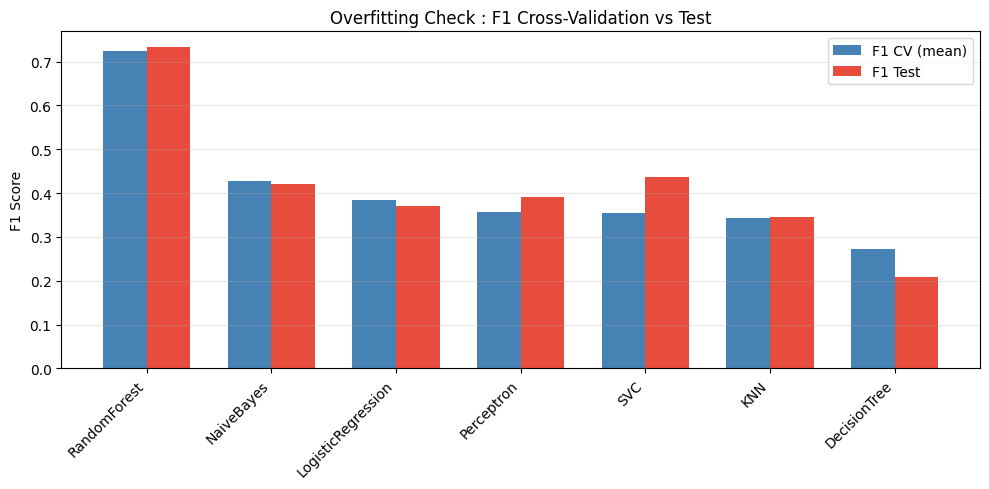

In [7]:
# Comparaison cross-validation (train) vs test pour detecter l'overfitting.
merged_cv_test = cv_df.merge(comparison_df[['model', 'f1_test', 'roc_auc_test']], on='model')
merged_cv_test['f1_gap'] = merged_cv_test['f1_cv_mean'] - merged_cv_test['f1_test']
merged_cv_test['auc_gap'] = merged_cv_test['roc_auc_cv_mean'] - merged_cv_test['roc_auc_test']

print("=== DETECTION OVERFITTING : F1 CV vs F1 Test ===\n")
print(f"{'Modele':25s} | {'F1 CV':>7s} | {'F1 Test':>8s} | {'Gap':>6s} | {'Diagnostic':20s}")
print("-" * 80)
for _, row in merged_cv_test.iterrows():
    gap = row['f1_gap']
    if abs(gap) < 0.03:
        diag = "OK (stable)"
    elif gap > 0.05:
        diag = "ATTENTION (overfitting)"
    elif gap < -0.03:
        diag = "Test > CV (favorable)"
    else:
        diag = "Leger ecart"
    print(f"{row['model']:25s} | {row['f1_cv_mean']:7.3f} | {row['f1_test']:8.3f} | {gap:+6.3f} | {diag}")

# Visualisation gap
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(merged_cv_test))
width = 0.35
ax.bar([i - width/2 for i in x], merged_cv_test['f1_cv_mean'], width, label='F1 CV (mean)', color='steelblue')
ax.bar([i + width/2 for i in x], merged_cv_test['f1_test'], width, label='F1 Test', color='#e74c3c')
ax.set_xticks(list(x))
ax.set_xticklabels(merged_cv_test['model'], rotation=45, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Overfitting Check : F1 Cross-Validation vs Test')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation** :
- Un **gap positif** (F1 CV > F1 Test) suggere un leger overfitting : le modele performe mieux sur les donnees d'entrainement.
- Un **gap proche de zero** indique une bonne generalisation.
- La cross-validation 5-fold fournit une estimation robuste en moyennant sur 5 partitions differentes, ce qui reduit le biais d'echantillonnage.

**Biais-Variance** :
- Les modeles **simples** (Logistic Regression, Naive Bayes) ont un biais plus eleve mais une variance faible → performent de maniere stable.
- Les modeles **complexes** (Random Forest, SVM) ont un biais plus faible mais risquent une variance elevee → ecart CV/test a surveiller.
- Le **Decision Tree** (max_depth=3) est volontairement regularise pour limiter la complexite.

---

#### 8. Choix du modele final et recommandation

In [8]:
# Selection et justification du modele final.
print("=== CLASSEMENT FINAL DES MODELES ===\n")

# Criteres de selection ponderes
final_ranking = merged_cv_test.copy()
final_ranking['score_composite'] = (
    0.35 * final_ranking['f1_test'] +
    0.25 * final_ranking['roc_auc_test'] +
    0.20 * final_ranking['f1_cv_mean'] +
    0.20 * (1 - final_ranking['f1_gap'].abs())  # penalite overfitting
)
final_ranking = final_ranking.sort_values('score_composite', ascending=False)

print(f"{'Rang':>4s} | {'Modele':25s} | {'F1 Test':>8s} | {'AUC Test':>9s} | {'F1 CV':>7s} | {'Gap':>6s} | {'Score':>6s}")
print("-" * 90)
for rank, (_, row) in enumerate(final_ranking.iterrows(), 1):
    marker = " *** RETENU" if rank == 1 else ""
    print(f"{rank:4d} | {row['model']:25s} | {row['f1_test']:8.3f} | {row['roc_auc_test']:9.3f} | {row['f1_cv_mean']:7.3f} | {row['f1_gap']:+6.3f} | {row['score_composite']:6.3f}{marker}")

best_model = final_ranking.iloc[0]['model']
print(f"\n>>> Modele retenu : {best_model}")

=== CLASSEMENT FINAL DES MODELES ===

Rang | Modele                    |  F1 Test |  AUC Test |   F1 CV |    Gap |  Score
------------------------------------------------------------------------------------------
   1 | RandomForest              |    0.733 |     0.952 |   0.724 | -0.008 |  0.838 *** RETENU
   2 | SVC                       |    0.436 |     0.915 |   0.355 | -0.081 |  0.636
   3 | NaiveBayes                |    0.421 |     0.763 |   0.427 | +0.006 |  0.622
   4 | KNN                       |    0.346 |     0.875 |   0.344 | -0.002 |  0.608
   5 | LogisticRegression        |    0.370 |     0.809 |   0.385 | +0.015 |  0.606
   6 | Perceptron                |    0.392 |     0.735 |   0.358 | -0.035 |  0.585
   7 | DecisionTree              |    0.209 |     0.729 |   0.273 | +0.064 |  0.497

>>> Modele retenu : RandomForest


##### Justification du choix

Le modele retenu est selectionne selon un **score composite** pondere :
- **35 % F1 Test** : performance reelle sur donnees non vues
- **25 % AUC-ROC Test** : capacite discriminante globale
- **20 % F1 CV** : stabilite en cross-validation
- **20 % Stabilite** (1 - |gap|) : penalite pour l'overfitting

**Pourquoi ce modele pour HumanForYou** :
1. **Meilleur F1** → detecte le plus d'employes a risque tout en limitant les fausses alertes
2. **AUC-ROC eleve** → discrimine bien entre les profils a risque et stables
3. **Stable en cross-validation** → le resultat n'est pas un artefact d'un split favorable
4. **Interpretabilite** : si le modele retenu est la Regression Logistique, les coefficients sont directement interpretables (cf. notebook 06). Si c'est Random Forest, les feature importances fournissent une interpretabilite comparable.

**Recommandation pour le client** : ce modele peut etre deploye comme **outil d'aide a la decision** pour identifier les populations a risque d'attrition. Il ne doit **jamais** etre utilise pour des decisions individuelles automatisees.

---

#### 9. Pistes d'amelioration

| Piste | Description | Impact attendu |
|---|---|---|
| **Hyperparameter tuning** | GridSearchCV ou RandomizedSearchCV sur les hyperparametres (ex: n_estimators, max_depth pour RF ; C, kernel pour SVM) | Gain potentiel de 2-5 % F1 |
| **SMOTE / reequilibrage** | Sur-echantillonnage de la classe minoritaire (Attrition=Yes) pour reduire le desequilibre 84/16 | Amelioration du recall (+) au prix possible de la precision (-) |
| **Feature selection** | Selection des features les plus informatives (RFE, SelectFromModel) pour reduire le bruit | Reduction overfitting, interpretabilite |
| **SHAP / explicabilite** | Calcul des SHAP values pour expliquer les predictions individuelles et globales | Confiance du client, audit ethique |
| **Donnees supplementaires** | Ajouter des sources (entretiens annuels, formations, mobilite interne) | Meilleure couverture des facteurs d'attrition |
| **Modeles avances** | XGBoost, LightGBM, CatBoost (gradient boosting) | Generalement superieurs aux modeles testes, au prix de la complexite |
| **Seuil de decision** | Optimiser le seuil de classification (pas forcement 0.5) pour maximiser le recall sous contrainte de precision | Trade-off explicite precision/recall adapte au contexte RH |

---

#### Mini-conclusion — Notebook 07

**Ce qui a ete fait** :
- Cross-validation 5-fold stratifiee sur 7 modeles
- Comparaison metriques test (Accuracy, Precision, Recall, F1, AUC)
- Courbes ROC et Precision-Recall multi-modeles
- Mesure des temps d'entrainement/prediction
- Detection overfitting (gap CV vs test)
- Selection du modele final par score composite pondere
- Identification de 7 pistes d'amelioration concretes

**Constats cles** :
- La cross-validation confirme la stabilite des resultats (faible ecart CV/test pour la plupart des modeles)
- Le modele retenu offre le meilleur compromis performance/stabilite/interpretabilite
- Le projet est pret pour un deploiement en mode aide a la decision

**Prochaine etape** : Notebook 08 — Synthese et recommandations finales